# 01 - Exploración geoespacial: sucursales de AFOREs (DENUE)

**Objetivo:** cargar el CSV nacional acumulado del DENUE (`data/processed/denue/`, todas las entidades federativas ya combinadas), validar calidad de datos, clasificar cada establecimiento por marca comercial de AFORE, y construir un mapa interactivo de México que permita filtrar por marca (ej. aislar solo **AFORE Profuturo**).

**Prerrequisito:** haber corrido `make download-denue` al menos una vez (ver [`docs/denue_ingestion.md`](../docs/denue_ingestion.md)). Genera, por entidad, el archivo completo (JSON + CSV) en `data/raw/denue/`, y en `data/processed/denue/` el CSV filtrado por marca por entidad más el CSV nacional acumulado (`denue_afore_nacional_<timestamp>.csv`).

In [13]:
import os
from pathlib import Path


def encontrar_raiz_proyecto(inicio: Path) -> Path:
    """Busca hacia arriba el directorio que contiene pyproject.toml."""
    for directorio in [inicio, *inicio.parents]:
        if (directorio / "pyproject.toml").exists():
            return directorio
    raise RuntimeError(
        f"No se encontró pyproject.toml subiendo desde {inicio}. "
        "Verifica que el notebook esté dentro del repo GeoEsp_DENUE."
    )


# Jupyter arranca el kernel con cwd = carpeta del notebook (notebooks/), no la
# raíz del repo ni el directorio desde el que se lanzó `jupyter lab`. Para que
# las rutas relativas (data/..., reports/...) funcionen igual en local, Docker
# o CI, fijamos el cwd al directorio del proyecto de forma explícita.
RAIZ_PROYECTO = encontrar_raiz_proyecto(Path.cwd())
os.chdir(RAIZ_PROYECTO)
print(f"cwd fijado a: {RAIZ_PROYECTO}")

cwd fijado a: /Users/antonioesparza/repos/Claude/GeoEsp_DENUE


In [14]:
import logging

import matplotlib.pyplot as plt
import pandas as pd

from src.caracteristicas.construir_caracteristicas import agregar_geometria
from src.preprocesamiento.limpiar_denue import (
    encontrar_csv_nacional_reciente,
    filtrar_afores,
    filtrar_coordenadas_validas,
)
from src.visualizacion.mapas_interactivos import construir_mapa_filtro_afore, guardar_mapa
from src.visualizacion.mapas_estaticos import graficar_mapa_puntos

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

## 1. Cargar el CSV nacional acumulado (todas las entidades)

`descargar_denue` ya escribe en `data/processed/denue/` un único CSV con todas las entidades federativas combinadas (`denue_afore_nacional_<timestamp>.csv`) — no hace falta concatenar un archivo por entidad. Usamos `encontrar_csv_nacional_reciente` para tomar el de la corrida más reciente.

In [15]:
directorio_procesado = RAIZ_PROYECTO / "data" / "processed" / "denue"
ruta_csv_nacional = encontrar_csv_nacional_reciente(directorio_procesado)

print(f"Archivo nacional más reciente: {ruta_csv_nacional.name}")

df_crudo = pd.read_csv(ruta_csv_nacional)
print(f"\nFilas: {len(df_crudo)} | Columnas: {len(df_crudo.columns)}")
df_crudo.head()

Archivo nacional más reciente: denue_afore_nacional_20260930_150832.csv

Filas: 48 | Columnas: 22


,CLEE,Id,Nombre,Razon_social,Clase_actividad,Estrato,Tipo_vialidad,Calle,Num_Exterior,Num_Interior,...,Ubicacion,Telefono,Correo_e,Sitio_internet,Tipo,Longitud,Latitud,tipo_corredor_industrial,nom_corredor_industrial,numero_local
0,09012524220000054000000000U4,6430761,AFORE AZTECA,AFORE AZTECA,Administración de cajas de pensión y de seguro...,251 y más personas,AVENIDA,EJE 3 SUR F. C. DE RIO FRIO,419.0,NaN,...,IZTAPALAPA ...,NaN,XMONTES@ELEKTRA.COM.MX,WWW.AFOREAZTECA.COM.MX,Fijo,-99.072080,19.386380,NaN,NaN,NaN
1,09015523910000171002014084S6,847194,AFORE BANAMEX,CITIBANAMEX AFORE,Administración de cajas de pensión y de seguro...,101 a 250 personas,AVENIDA,PASEO DE LA REFORMA,381.0,NaN,...,CUAUHTÉMOC ...,NaN,AFOREENLINEA@CITIBANAMEX.COM,WWW.AFOREBANAMEX.COM.MX,Fijo,-99.169872,19.426376,NaN,NaN,NaN
2,09005524220000021001053469S7,846335,AFORE COPPEL,AFORE COPPEL,Administración de cajas de pensión y de seguro...,101 a 250 personas,AVENIDA,CUAUTEPEC,201.0,NaN,...,GUSTAVO A. MADERO ...,NaN,NaN,NaN,Fijo,-99.142017,19.526015,NaN,NaN,NaN
3,09003524220000021001053469S2,1059115,AFORE COPPEL,AFORE COPPEL,Administración de cajas de pensión y de seguro...,101 a 250 personas,AVENIDA,GRAN SUR,5550.0,NaN,...,COYOACÁN ...,NaN,NaN,NaN,Fijo,-99.164127,19.307412,CENTRO Y PLAZA COMERCIAL,COPPEL GRAN SUR,SN
4,09002524220000011101053469M5,846273,AFORE COPPEL,AFORE COPPEL,Administración de cajas de pensión y de seguro...,251 y más personas,AVENIDA,JOSE MARTI,287.0,NaN,...,MIGUEL HIDALGO ...,NaN,NORMATIVIDAD@BANCOPPEL.COM,NaN,Fijo,-99.171041,19.400062,NaN,NaN,NaN


## 2. Calidad de datos (DQ)

Antes de transformar nada: revisar columnas disponibles, nulos y duplicados.

In [16]:
print("Columnas:", list(df_crudo.columns))
print()
print("Nulos por columna:")
print(df_crudo.isnull().sum().sort_values(ascending=False))
print()
print(f"Duplicados por Id: {df_crudo['Id'].duplicated().sum()}")

Columnas: ['CLEE', 'Id', 'Nombre', 'Razon_social', 'Clase_actividad', 'Estrato', 'Tipo_vialidad', 'Calle', 'Num_Exterior', 'Num_Interior', 'Colonia', 'CP', 'Ubicacion', 'Telefono', 'Correo_e', 'Sitio_internet', 'Tipo', 'Longitud', 'Latitud', 'tipo_corredor_industrial', 'nom_corredor_industrial', 'numero_local']

Nulos por columna:
Num_Interior                45
Telefono                    36
nom_corredor_industrial     36
numero_local                35
tipo_corredor_industrial    35
Sitio_internet              29
Correo_e                    29
Razon_social                 2
Num_Exterior                 1
Latitud                      0
Longitud                     0
Tipo                         0
CLEE                         0
Ubicacion                    0
Id                           0
Colonia                      0
Calle                        0
Tipo_vialidad                0
Estrato                      0
Clase_actividad              0
Nombre                       0
CP              

## 3. Limpieza: coordenadas válidas y clasificación por marca de AFORE

Dos pasos, implementados en `src/preprocesamiento/limpiar_denue.py` (con pruebas en `tests/test_limpiar_denue.py`):

1. `filtrar_coordenadas_validas`: descarta filas con lat/lon nulas, en cero, o fuera del territorio mexicano.
2. `filtrar_afores`: agrega `afore_marca` (clasificación por texto contra `Nombre`/`Razon_social`), y `municipio`/`estado` (parseados del campo `Ubicacion`).

**Nota:** el endpoint del DENUE hace *match* de texto libre, así que aparecerá ruido (asesorías, trámites, nombres genéricos) que cae en `OTRO / SIN CLASIFICAR`. Ver limitaciones en [`docs/denue_ingestion.md`](../docs/denue_ingestion.md).

In [17]:
n_crudo = len(df_crudo)

df_limpio = filtrar_coordenadas_validas(df_crudo)
n_coords_validas = len(df_limpio)

df_limpio = filtrar_afores(df_limpio)

# Cifras control (DQ) - regla obligatoria de CLAUDE.md
print("=== Cifras control ===")
print(f"Registros descargados:              {n_crudo}")
print(f"Con coordenadas válidas en México:  {n_coords_validas} ({n_crudo - n_coords_validas} descartados)")
print(f"Marcas de AFORE detectadas:         {df_limpio['afore_marca'].nunique()}")

=== Cifras control ===
Registros descargados:              48
Con coordenadas válidas en México:  48 (0 descartados)
Marcas de AFORE detectadas:         10


## 4. Distribución por marca de AFORE

In [18]:
conteo_marcas = df_limpio["afore_marca"].value_counts()
conteo_marcas

afore_marca
XXI BANORTE              13
CITIBANAMEX               9
PROFUTURO                 6
SURA                      5
PRINCIPAL                 4
COPPEL                    3
INBURSA                   3
INVERCAP                  3
AZTECA                    1
OTRO / SIN CLASIFICAR     1
Name: count, dtype: int64

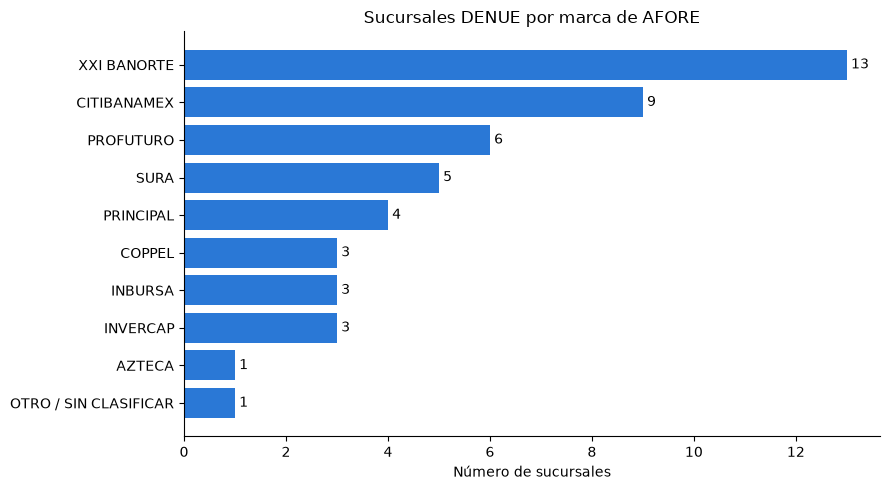

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(conteo_marcas.index[::-1], conteo_marcas.values[::-1], color="#2a78d6")
ax.bar_label(barras, padding=3)
ax.set_xlabel("Número de sucursales")
ax.set_title("Sucursales DENUE por marca de AFORE")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Distribución por entidad federativa (EDA adicional)

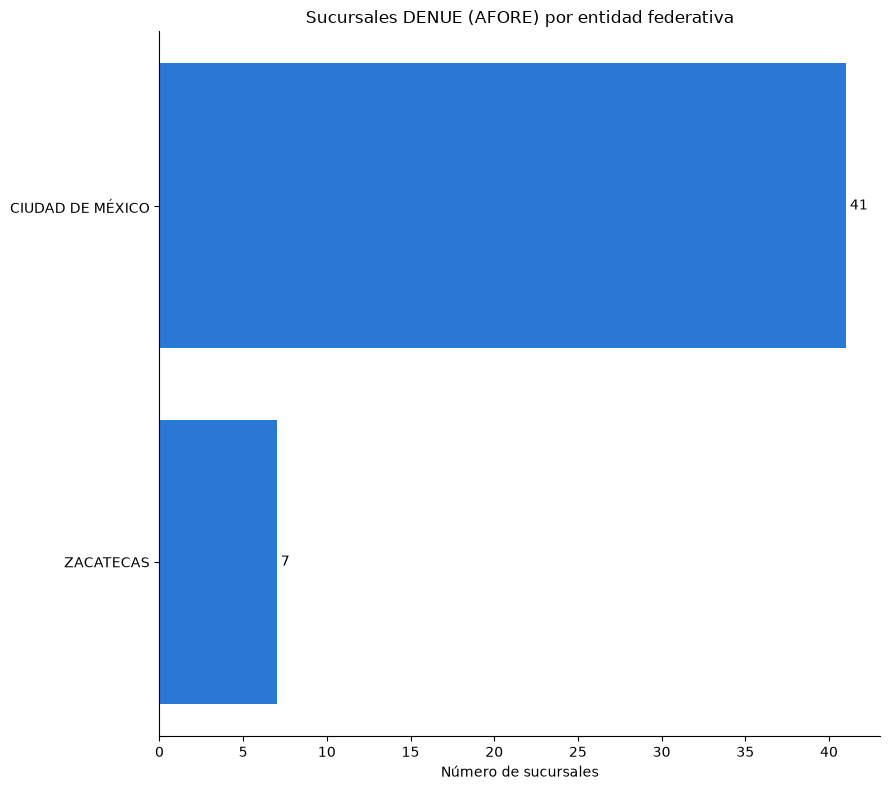

In [20]:
conteo_estados = df_limpio["estado"].value_counts()

fig, ax = plt.subplots(figsize=(9, 8))
barras = ax.barh(conteo_estados.index[::-1], conteo_estados.values[::-1], color="#2a78d6")
ax.bar_label(barras, padding=3)
ax.set_xlabel("Número de sucursales")
ax.set_title("Sucursales DENUE (AFORE) por entidad federativa")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Construir el GeoDataFrame

`agregar_geometria` (en `src/caracteristicas/construir_caracteristicas.py`) convierte `Longitud`/`Latitud` en geometría de puntos, en WGS84 (`EPSG:4326`) — el CRS geográfico definido en `config/crs_config.yaml`.

In [21]:
gdf_afores = agregar_geometria(df_limpio)
print(f"CRS: {gdf_afores.crs}")
gdf_afores[["Nombre", "afore_marca", "municipio", "estado", "geometry"]].head()

CRS: EPSG:4326


,Nombre,afore_marca,municipio,estado,geometry
0,AFORE AZTECA,AZTECA,Iztapalapa,CIUDAD DE MÉXICO,POINT (-99.07208 19.38638)
1,AFORE BANAMEX,CITIBANAMEX,Cuauhtémoc,CIUDAD DE MÉXICO,POINT (-99.16987 19.42638)
2,AFORE COPPEL,COPPEL,Gustavo A. Madero,CIUDAD DE MÉXICO,POINT (-99.14202 19.52601)
3,AFORE COPPEL,COPPEL,Coyoacán,CIUDAD DE MÉXICO,POINT (-99.16413 19.30741)
4,AFORE COPPEL,COPPEL,Miguel Hidalgo,CIUDAD DE MÉXICO,POINT (-99.17104 19.40006)


In [22]:
ruta_procesado = RAIZ_PROYECTO / "data" / "processed" / "afores_denue.gpkg"
ruta_procesado.parent.mkdir(parents=True, exist_ok=True)
gdf_afores.to_file(ruta_procesado, driver="GPKG")
print(f"Guardado: {ruta_procesado} ({len(gdf_afores)} filas)")

2026-09-30 15:56:35,180 | INFO | Created 48 records


Guardado: /Users/antonioesparza/repos/Claude/GeoEsp_DENUE/data/processed/afores_denue.gpkg (48 filas)


## 7. Mapa estático rápido (sanity check)

Antes del mapa interactivo, un vistazo estático de todos los puntos (un solo color, sin categorías — ver `src/visualizacion/mapas_estaticos.py`).

Mapa estático guardado en /Users/antonioesparza/repos/Claude/GeoEsp_DENUE/reports/figures/afores_overview.png


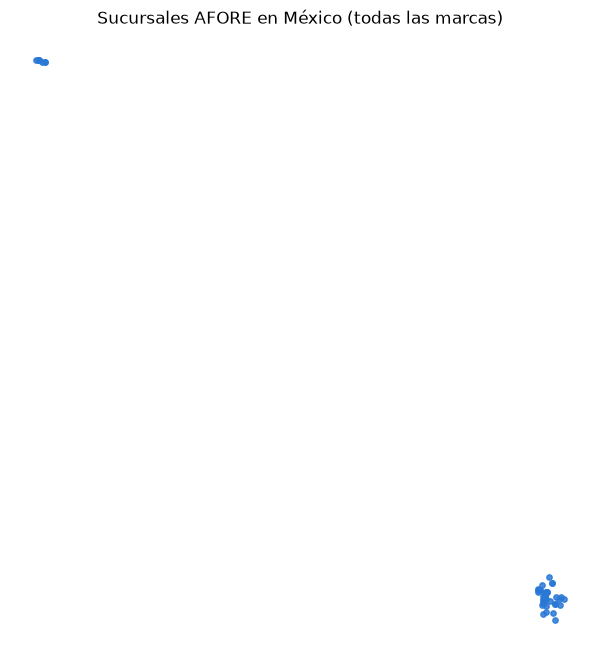

In [23]:
ruta_mapa_estatico = RAIZ_PROYECTO / "reports" / "figures" / "afores_overview.png"
graficar_mapa_puntos(
    gdf_afores,
    ruta_salida=ruta_mapa_estatico,
    titulo="Sucursales AFORE en México (todas las marcas)",
)
print(f"Mapa estático guardado en {ruta_mapa_estatico}")

## 8. Mapa interactivo filtrable por marca de AFORE

Cada marca es una capa independiente (`FeatureGroup`). En el panel de capas (arriba a la derecha del mapa) puedes **desmarcar todas las AFORE excepto "PROFUTURO"** para aislarla, o combinar varias para comparar.

El mapa también queda guardado como HTML standalone en `reports/maps/`, para abrir en el navegador o compartir sin necesitar Jupyter.

In [24]:
mapa = construir_mapa_filtro_afore(gdf_afores)

ruta_mapa_interactivo = RAIZ_PROYECTO / "reports" / "maps" / "afores_mexico_interactive.html"
guardar_mapa(mapa, ruta_mapa_interactivo)

mapa

2026-09-30 15:56:51,739 | INFO | Mapa generado: 10 marcas, 48 sucursales totales
2026-09-30 15:56:51,772 | INFO | Mapa guardado en /Users/antonioesparza/repos/Claude/GeoEsp_DENUE/reports/maps/afores_mexico_interactive.html


## 9. Próximos pasos

- **Validar cobertura:** comparar `conteo_marcas` contra el listado oficial de las 10 AFOREs autorizadas por CONSAR; revisar manualmente el bucket `OTRO / SIN CLASIFICAR` y variantes con errores tipográficos (ej. "C0PPEL").
- **`02_limpieza.ipynb`:** formalizar reglas DQ adicionales y umbrales de aceptación (ver `CLAUDE.md`).
- **`03_analisis_geoespacial.ipynb`:** usar `gdf_afores` (o `data/processed/afores_denue.gpkg`) para análisis de densidad, cercanía y cobertura (`src/analisis_geoespacial/`).
- **Evidencia:** este notebook, `reports/figures/afores_overview.png` y `reports/maps/afores_mexico_interactive.html` son la evidencia verificable de esta etapa (ver `CLAUDE.md`).